In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav_df = pd.read_csv(
    "../data/processed/nav_history.csv",
    parse_dates=["date"]
)

In [3]:
print("Shape:", nav_df.shape)

print("\nColumns:")
print(nav_df.columns.tolist())

print("\nData Types:")
print(nav_df.dtypes)

display(nav_df.head())

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Data Types:
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
).reset_index(drop=True)

In [5]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [6]:
display(
    nav_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)

print(nav_df["daily_return"].describe())

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [7]:
var_results = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    var_results.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar_df = pd.DataFrame(var_results)

In [8]:
var_cvar_df = (
    var_cvar_df
    .sort_values("VaR_95")
    .reset_index(drop=True)
)

display(var_cvar_df.head(10))

,amfi_code,VaR_95,CVaR_95
0,119599,-0.026859,-0.032384
1,119095,-0.026188,-0.031667
2,101207,-0.026021,-0.032459
3,118634,-0.025438,-0.032304
4,119598,-0.024507,-0.030595
5,149324,-0.023483,-0.031036
6,102886,-0.019220,-0.023251
7,100033,-0.019034,-0.023456
8,120505,-0.018892,-0.024342
9,119094,-0.018480,-0.024260


In [9]:
output_path = "../outputs/reports/var_cvar_report.csv"

var_cvar_df.to_csv(
    output_path,
    index=False
)

print(f"Report saved to: {output_path}")

Report saved to: ../outputs/reports/var_cvar_report.csv


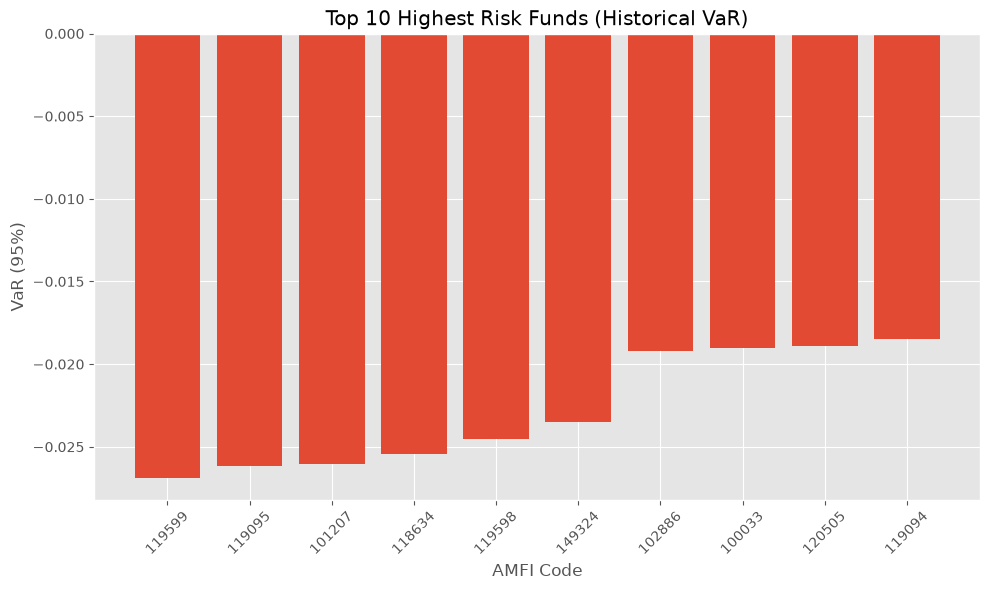

In [10]:
top10 = var_cvar_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["VaR_95"]
)

plt.title("Top 10 Highest Risk Funds (Historical VaR)")
plt.xlabel("AMFI Code")
plt.ylabel("VaR (95%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

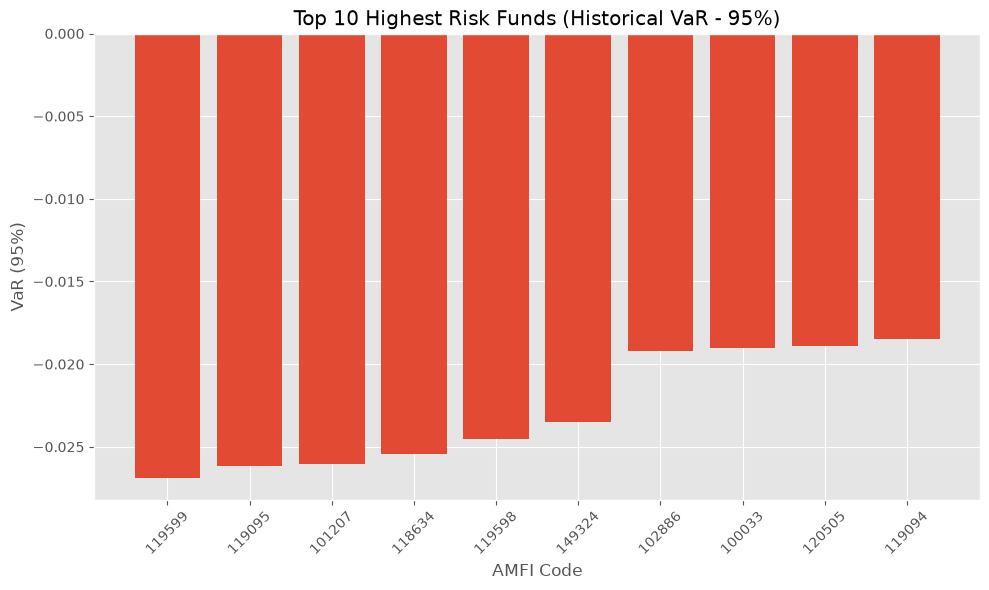

Chart saved to: ../outputs/charts/historical_var_top10.png


In [11]:
# Top 10 funds with highest historical risk (lowest VaR)
top10 = var_cvar_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["VaR_95"]
)

plt.title("Top 10 Highest Risk Funds (Historical VaR - 95%)")
plt.xlabel("AMFI Code")
plt.ylabel("VaR (95%)")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
chart_path = "../outputs/charts/historical_var_top10.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved to: {chart_path}")

section 2 - rolling 90-day sharpe ratio 


In [12]:
if "daily_return" not in nav_df.columns:
    nav_df = nav_df.sort_values(["amfi_code", "date"])
    nav_df["daily_return"] = (
        nav_df.groupby("amfi_code")["nav"]
              .pct_change()
    )

In [13]:
rolling_sharpe_list = []

for fund, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    rolling_mean = group["daily_return"].rolling(90).mean()
    rolling_std = group["daily_return"].rolling(90).std()

    group["rolling_sharpe"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    rolling_sharpe_list.append(group)

rolling_sharpe_df = pd.concat(
    rolling_sharpe_list,
    ignore_index=True
)

In [14]:
rolling_sharpe_df[
    ["amfi_code", "date", "rolling_sharpe"]
].head()

,amfi_code,date,rolling_sharpe
0,100016,2022-01-03,NaN
1,100016,2022-01-04,NaN
2,100016,2022-01-05,NaN
3,100016,2022-01-06,NaN
4,100016,2022-01-07,NaN


In [15]:
key_funds = (
    rolling_sharpe_df["amfi_code"]
    .drop_duplicates()
    .sort_values()
    .head(5)
    .tolist()
)

print(key_funds)

[100016, 100025, 100033, 101206, 101207]


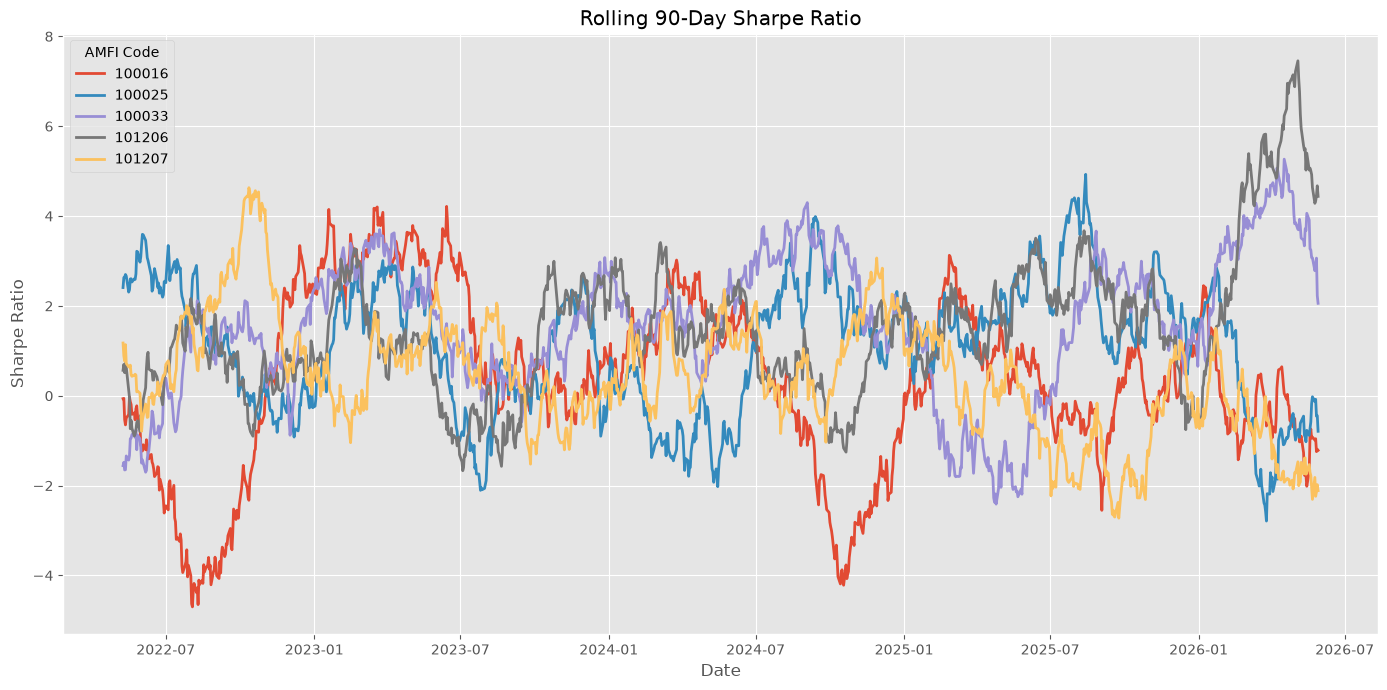

In [16]:
plt.figure(figsize=(14, 7))

for fund in key_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund),
        linewidth=2
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()

section-3 investor cohort analysis

In [18]:
transactions_df = pd.read_csv(
    "../data/processed/investor_transactions.csv",
    parse_dates=["transaction_date"]
)

print(transactions_df.shape)
print(transactions_df.columns.tolist())

display(transactions_df.head())

(32778, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000081,2024-01-01,120844,SIP,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified
1,INV000097,2024-01-01,125498,Redemption,527377,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified
2,INV000234,2024-01-01,148567,SIP,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified
3,INV000368,2024-01-01,118636,Redemption,339882,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified
4,INV000428,2024-01-01,118636,SIP,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified


In [20]:
funds_df = pd.read_csv("../data/processed/fund_master.csv")

print(funds_df.columns.tolist())

display(funds_df.head())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [22]:
first_txn = (
    transactions_df
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

transactions_df = transactions_df.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

In [24]:
preferred_fund = (
    transactions_df
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
)

preferred_fund = (
    preferred_fund
    .sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

preferred_fund = preferred_fund.merge(
    funds_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [26]:
cohort_summary = (
    transactions_df
    .groupby("cohort_year")
    .agg(
        average_sip_amount=("transaction_amount", "mean"),
        total_invested=("transaction_amount", "sum")
    )
    .reset_index()
)

cohort_summary = cohort_summary.merge(
    preferred_fund[
        ["cohort_year", "scheme_name"]
    ],
    on="cohort_year",
    how="left"
)

cohort_summary.rename(
    columns={
        "scheme_name": "most_preferred_fund"
    },
    inplace=True
)

display(cohort_summary)

KeyError: "Label(s) ['transaction_amount'] do not exist"

In [27]:
print(transactions_df.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [29]:
cohort_summary = (
    transactions_df
    .groupby("cohort_year")
    .agg(
        average_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary = cohort_summary.merge(
    preferred_fund[
        ["cohort_year", "scheme_name"]
    ],
    on="cohort_year",
    how="left"
)

cohort_summary.rename(
    columns={
        "scheme_name": "most_preferred_fund"
    },
    inplace=True
)

display(cohort_summary)

,cohort_year,average_sip_amount,total_invested,most_preferred_fund
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [31]:
report_path = "../outputs/reports/investor_cohort_analysis.csv"

cohort_summary.to_csv(
    report_path,
    index=False
)

print(f"Report saved to: {report_path}")

Report saved to: ../outputs/reports/investor_cohort_analysis.csv


section 4 - SIP Continuity analysis 

In [33]:
sip_df = transactions_df[
    transactions_df["transaction_type"].str.upper() == "SIP"
].copy()

print("SIP Transactions:", sip_df.shape)
display(sip_df.head())

SIP Transactions: (19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000081,2024-01-01,120844,SIP,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified,2024
2,INV000234,2024-01-01,148567,SIP,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified,2024
4,INV000428,2024-01-01,118636,SIP,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified,2024
5,INV000437,2024-01-01,120504,SIP,900,Telangana,Hyderabad,T30,26-35,Female,6.1,UPI,Verified,2024
6,INV000467,2024-01-01,119552,SIP,2623,Karnataka,Bangalore,T30,18-25,Female,7.1,Cheque,Verified,2024


In [35]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
).reset_index(drop=True)

In [37]:
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
          .diff()
          .dt.days
)

In [39]:
sip_summary = (
    sip_df.groupby("investor_id")
          .agg(
              sip_count=("transaction_date", "count"),
              average_gap_days=("gap_days", "mean")
          )
          .reset_index()
)

In [41]:
sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
].copy()

In [43]:
sip_summary["status"] = np.where(
    sip_summary["average_gap_days"] > 35,
    "At Risk",
    "Regular"
)

In [45]:
display(sip_summary.head(10))

print("\nStatus Count:")
print(sip_summary["status"].value_counts())

,investor_id,sip_count,average_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk
12,INV000013,7,55.333333,At Risk
13,INV000014,7,75.333333,At Risk
22,INV000023,8,58.571429,At Risk
27,INV000028,6,93.600000,At Risk
28,INV000029,7,60.666667,At Risk



Status Count:
status
At Risk    1332
Regular      30
Name: count, dtype: int64


In [47]:
report_path = "../outputs/reports/sip_continuity_analysis.csv"

sip_summary.to_csv(
    report_path,
    index=False
)

print(f"Report saved to: {report_path}")

Report saved to: ../outputs/reports/sip_continuity_analysis.csv


section -5 simple fund recommender 

In [49]:
print(funds_df.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [51]:
sharpe_df = pd.read_csv("../outputs/reports/sharpe_ratio.csv")

print(sharpe_df.columns.tolist())
display(sharpe_df.head())

['amfi_code', 'scheme_name', 'annual_return', 'annual_volatility', 'sharpe_ratio', 'Rank']


,amfi_code,scheme_name,annual_return,annual_volatility,sharpe_ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101,5


In [53]:
print(sorted(funds_df["risk_category"].dropna().unique()))

['High', 'Low', 'Moderate', 'Moderately High', 'Very High']


In [55]:
sector_df = pd.read_csv("../data/processed/sector_allocation.csv")

print(sector_df.shape)
print(sector_df.columns.tolist())

display(sector_df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/sector_allocation.csv'

In [56]:
import os

processed_path = "../data/processed"

print("Processed files:\n")
for file in sorted(os.listdir(processed_path)):
    print(file)

Processed files:

aum_by_fund_house.csv
benchmark_indices.csv
category_inflows.csv
fund_master.csv
industry_folio_count.csv
investor_transactions.csv
monthly_sip_inflows.csv
nav_history.csv
portfolio_holdings.csv
scheme_performance.csv


In [58]:
portfolio_df = pd.read_csv("../data/processed/portfolio_holdings.csv")

print(portfolio_df.shape)
print(portfolio_df.columns.tolist())

display(portfolio_df.head())

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


section -6 Sector HHI concentration

In [60]:
portfolio_df = pd.read_csv("../data/processed/portfolio_holdings.csv")

print(portfolio_df.shape)
print(portfolio_df.columns.tolist())

display(portfolio_df.head())

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
portfolio_df["weight_fraction"] = portfolio_df["weight_pct"] / 100

In [64]:
hhi_df = (
    portfolio_df
    .groupby("amfi_code")
    .agg(
        hhi=("weight_fraction", lambda x: (x**2).sum()),
        number_of_holdings=("stock_symbol", "count")
    )
    .reset_index()
)

In [66]:
hhi_df = hhi_df.merge(
    funds_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi_df = hhi_df[
    [
        "amfi_code",
        "scheme_name",
        "number_of_holdings",
        "hhi"
    ]
]

In [68]:
def concentration_level(hhi):
    if hhi < 0.15:
        return "Diversified"
    elif hhi < 0.25:
        return "Moderately Concentrated"
    else:
        return "Highly Concentrated"

hhi_df["concentration"] = hhi_df["hhi"].apply(concentration_level)

In [70]:
hhi_df = hhi_df.sort_values(
    "hhi",
    ascending=False
).reset_index(drop=True)

display(hhi_df)

,amfi_code,scheme_name,number_of_holdings,hhi,concentration
0,119092,Axis Bluechip Fund - Regular - Growth,10,0.206448,Moderately Concentrated
1,101207,ABSL Small Cap Fund - Regular - Growth,8,0.200700,Moderately Concentrated
2,119599,SBI Small Cap Fund - Direct Plan - Growth,8,0.174751,Moderately Concentrated
3,102885,UTI Nifty 50 Index Fund - Regular - Growth,9,0.174709,Moderately Concentrated
4,118632,Nippon India Large Cap Fund - Regular - Growth,8,0.168298,Moderately Concentrated
5,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,8,0.167930,Moderately Concentrated
6,120505,ICICI Pru Midcap Fund - Regular - Growth,8,0.157570,Moderately Concentrated
7,120506,ICICI Pru Value Discovery Fund - Regular - Growth,9,0.153794,Moderately Concentrated
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,8,0.152414,Moderately Concentrated
9,120841,Kotak Bluechip Fund - Regular - Growth,10,0.149680,Diversified


In [72]:
report_path = "../outputs/reports/sector_hhi_report.csv"

hhi_df.to_csv(report_path, index=False)

print(f"Report saved to: {report_path}")

Report saved to: ../outputs/reports/sector_hhi_report.csv


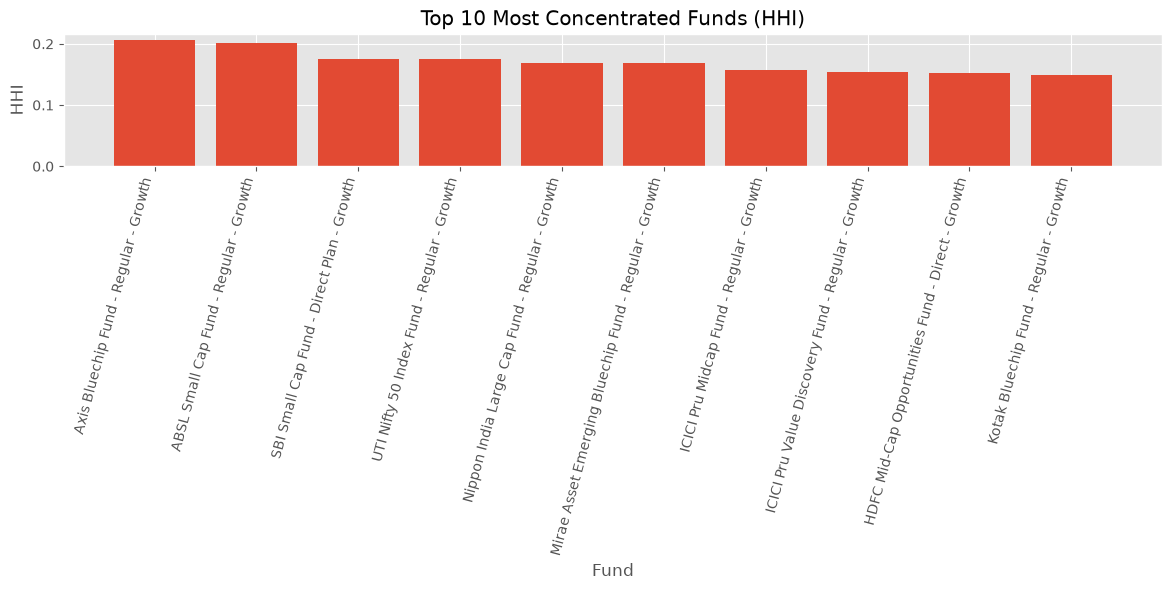

Chart saved to: ../outputs/charts/sector_hhi_concentration.png


In [74]:
top10 = hhi_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["hhi"]
)

plt.title("Top 10 Most Concentrated Funds (HHI)")
plt.xlabel("Fund")
plt.ylabel("HHI")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

chart_path = "../outputs/charts/sector_hhi_concentration.png"

plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved to: {chart_path}")

In [75]:
chart_path = "../outputs/charts/rolling_sharpe_chart.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

<Figure size 640x480 with 0 Axes>

Chart saved to: ../outputs/charts/rolling_sharpe_chart.png
